In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# 查看原始图像与对抗样本的差异
import matplotlib.pyplot as plt
import numpy as np

def show_images(original, adversarial):
    """ 可视化原始样本和对抗样本 """
    fig, axs = plt.subplots(1, 2, figsize=(6, 3))

    # 转换格式以便 Matplotlib 显示
    orig_np = original.squeeze(0).detach().cpu().permute(1, 2, 0).numpy()
    adv_np = adversarial.squeeze(0).detach().cpu().permute(1, 2, 0).numpy()
    
    axs[0].imshow(np.clip(orig_np, 0, 1))
    axs[0].set_title("Original Image")
    
    axs[1].imshow(np.clip(adv_np, 0, 1))
    axs[1].set_title("Adversarial Image")
    
    plt.show()

# 定义一个简单的 LeNet 模型
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

def visualize_attack(x, x_adv):
    """
    可视化原始样本、对抗样本及其扰动
    """
    x_np = x.squeeze(0).detach().cpu().numpy().transpose(1, 2, 0)  # 转换为 (H, W, C)
    x_adv_np = x_adv.squeeze(0).detach().cpu().numpy().transpose(1, 2, 0)
    perturbation = np.abs(x_adv_np - x_np)

    # 归一化扰动以便可视化
    perturbation /= perturbation.max() + 1e-8

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(np.clip(x_np, 0, 1))
    axes[0].set_title("Original Image")

    axes[1].imshow(np.clip(x_adv_np, 0, 1))
    axes[1].set_title("Adversarial Image")

    axes[2].imshow(perturbation, cmap="inferno")
    axes[2].set_title("Perturbation (Amplified)")

    plt.show()

# 初始化模型
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)

# 随机生成样本
x = torch.rand((1, 3, 32, 32)).to(device)  # 输入样本
y = torch.tensor([1], device=device)  # 真实标签


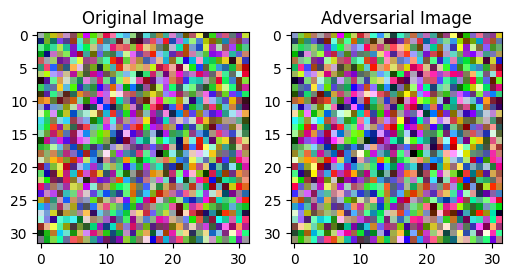

The maximum difference between x and x_adv is 0.10000.
x: [0.6326032  0.36997736 0.7568777  ... 0.37378514 0.7803589  0.63125557]
x_adv_pgd: [0.5326032  0.46997735 0.6568777  ... 0.47378513 0.88035893 0.53125554]
Prediction on x: 6
Prediction on x_adv: 7


In [2]:

# FGSM 攻击函数
def fgsm_attack(model, x, y, epsilon):
    """
    使用 FGSM 生成对抗样本。
    """
    x = x.clone().detach().requires_grad_(True)  # 确保 x 可以计算梯度
    output = model(x)  # 前向传播
    loss = F.cross_entropy(output, y)  # 计算损失

    model.zero_grad()
    loss.backward()  # 计算损失的梯度

    # 计算扰动方向并更新输入
    x_adv = x + epsilon * x.grad.sign()
    return torch.clamp(x_adv, 0, 1)  # 限制像素值范围

# 进行 FGSM 攻击
epsilon = 0.1
x_adv = fgsm_attack(model, x, y, epsilon)



show_images(x, x_adv)

# show the difference
diff = (x - x_adv).abs().max()
print(f"The maximum difference between x and x_adv is {diff:.5f}.")

# show x and x_adv_pgd in numbers
print(f"x: {x.detach().cpu().numpy().reshape(-1)}")
print(f"x_adv_pgd: {x_adv.detach().cpu().numpy().reshape(-1)}")

# show the prediction
output = model(x)
output_adv = model(x_adv)
print(f"Prediction on x: {output.argmax()}")
print(f"Prediction on x_adv: {output_adv.argmax()}")


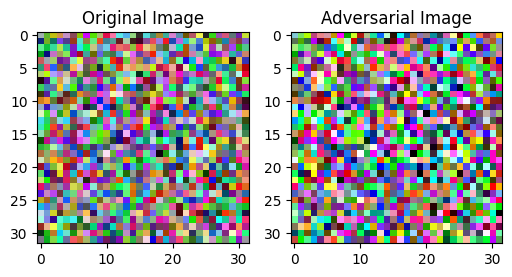

The maximum difference between x and x_adv_pgd is 0.30000.
x: [0.6326032  0.36997736 0.7568777  ... 0.37378514 0.7803589  0.63125557]
x_adv_pgd: [0.51260334 0.46997726 0.6968778  ... 0.17378521 1.         0.33125556]
Prediction on x: 6
Prediction on x_adv: 7


In [3]:
# PGD 攻击函数
def pgd_attack(model, x, y, epsilon=0.1, alpha=0.01, num_iter=10):
    """
    PGD 迭代攻击
    """
    x_adv = x.clone().detach().requires_grad_(True)
    
    for _ in range(num_iter):
        output = model(x_adv)
        loss = F.cross_entropy(output, y)
        
        model.zero_grad()
        loss.backward()
        
        # 更新扰动
        x_adv = x_adv + alpha * x_adv.grad.sign()
        
        # 投影到 L_inf 球
        x_adv = torch.clamp(x_adv, x - epsilon, x + epsilon)
        
        # 限制像素范围
        x_adv = torch.clamp(x_adv, 0, 1).detach().requires_grad_(True)
    
    return x_adv

# 运行 PGD 攻击
epsilon = 0.3  # FGSM 一般取 0.1，PGD 可能需要更大
alpha = 0.01  # 每步的扰动
num_iter = 50  # 迭代次数
x_adv_pgd = pgd_attack(model, x, y, epsilon, alpha, num_iter)


# x_adv_pgd = pgd_attack(model, x, y, epsilon=0.1, alpha=0.02, num_iter=10)
show_images(x, x_adv_pgd)

# 计算最大扰动
diff = (x - x_adv_pgd).abs().max()
print(f"The maximum difference between x and x_adv_pgd is {diff:.5f}.")

# show x and x_adv_pgd in numbers
print(f"x: {x.detach().cpu().numpy().reshape(-1)}")
print(f"x_adv_pgd: {x_adv_pgd.detach().cpu().numpy().reshape(-1)}")

# show the prediction
output = model(x)
output_adv = model(x_adv_pgd)
print(f"Prediction on x: {output.argmax()}")
print(f"Prediction on x_adv: {output_adv.argmax()}")
